In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Borajin\.cache\kagglehub\datasets\sartajbhuvaji\brain-tumor-classification-mri\versions\2


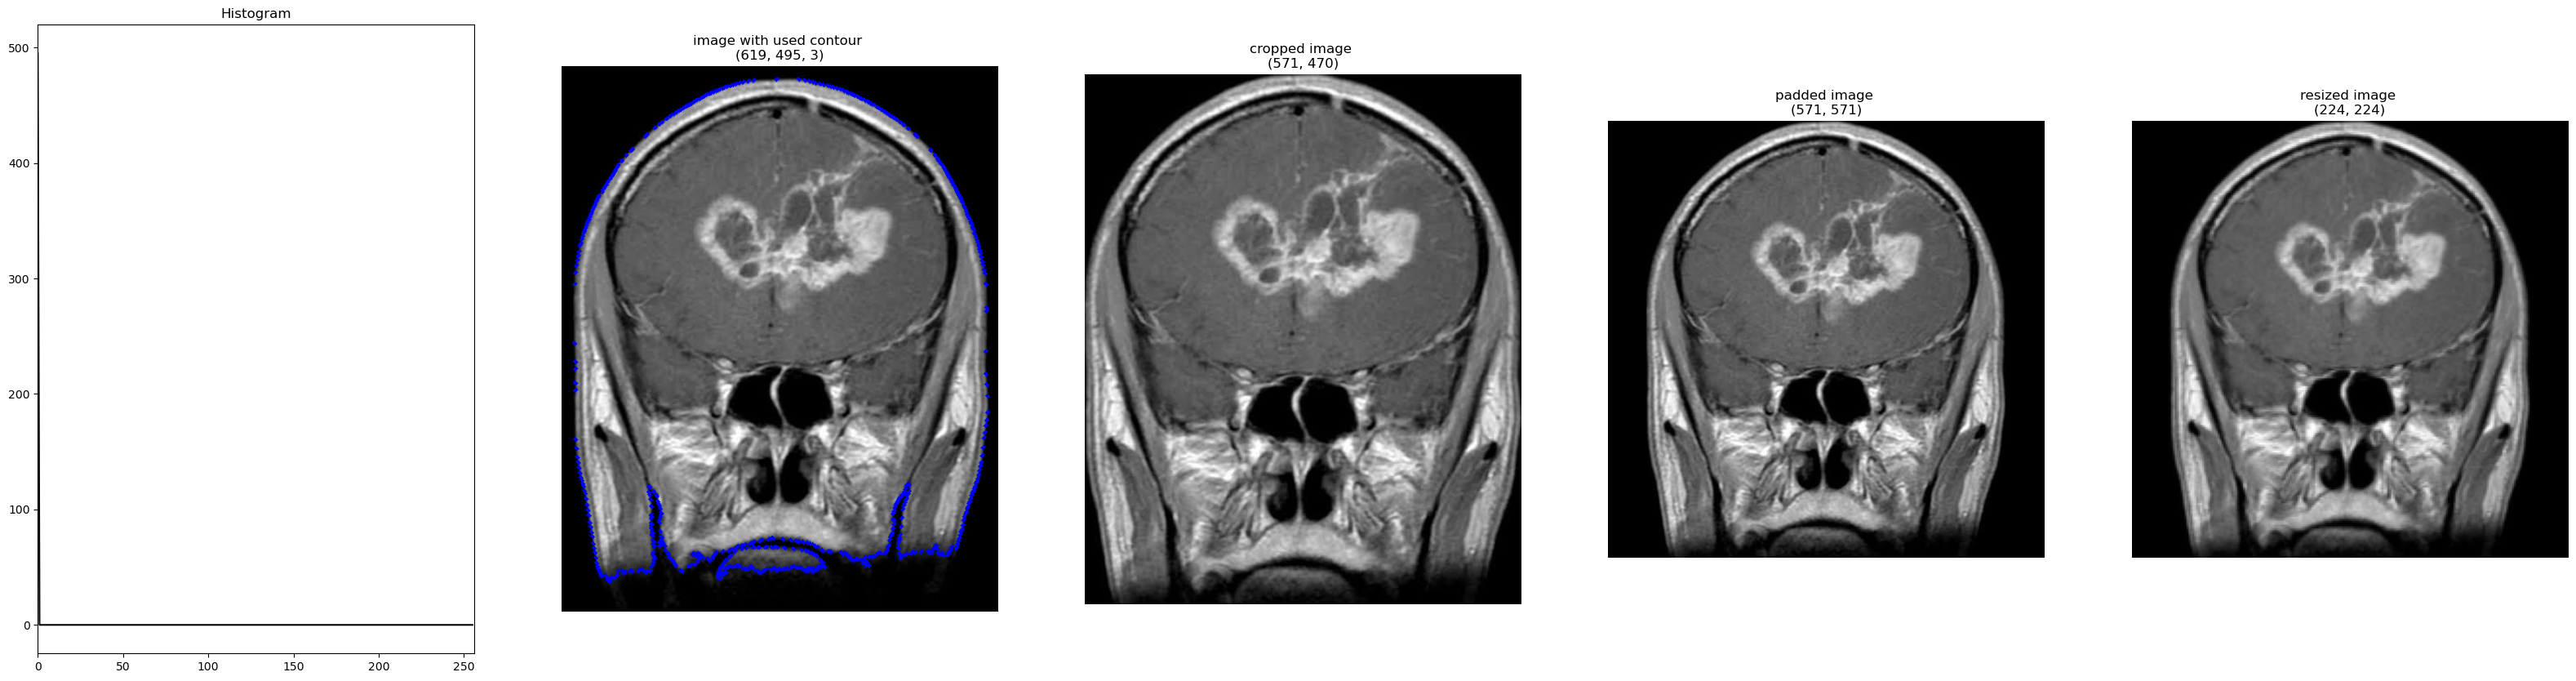

In [133]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

def retrieve_image_paths(input_path):
    image_paths = []
    
    if not os.path.exists(input_path):
        print("Error opening given directory path: {}".format(input_path))
        return
    
    for entry in os.listdir(input_path):
        current_path = os.path.join(input_path, entry)
        if os.path.isdir(current_path):
            image_paths.extend(retrieve_image_paths(current_path))
        elif os.path.isfile(current_path) and current_path.endswith(".jpg"):
            image_paths.append(current_path)
            
    return image_paths

def process_image(image_path, show_plots=False):
    try:
        # Open the image
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        # extract binary image
        _, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY) # TODO werte myb auslagern
        hist = cv2.calcHist(img, [0], None, [256], [0, 256])

        # find contours
        contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # select contour enclosing largest area
        largest_contour = max(contours, key=cv2.contourArea)
        rgb_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        visualization_image = cv2.drawContours(rgb_image, largest_contour, -1, (0, 0, 255), 3)
        
        # get border of rectangle, which would enclose the contour
        x, y, w, h = cv2.boundingRect(largest_contour)
                
        # make sure, coordinates are inside image
        x, y = max(0, x), max(0, y)
        w, h = min(w, img.shape[1]-x), min(h, img.shape[0]-y)
        
        # crop
        cropped = img[y:y+h, x:x+w]
        
        # create padding for height or width, ensure to reach same size                 
        padding = np.abs(h-w)/2
        padding1 = int(np.floor(padding))
        padding2 = int(np.ceil(padding))
        
        # pad either height or width
        if h > w:
            padded = cv2.copyMakeBorder(cropped, 0, 0, padding1, padding2, cv2.BORDER_CONSTANT)
        else:
            padded = cv2.copyMakeBorder(cropped, padding1, padding2, 0, 0, cv2.BORDER_CONSTANT)
        
        # resize to wanted shape
        wanted_shape = (224, 224)
        resized = cv2.resize(padded, wanted_shape, interpolation=cv2.INTER_AREA)
        
        if show_plots:  # Only show plots if explicitly requested
            i=0
            fig, axes = plt.subplots(1, 5, figsize=(40, 10))
            axes[i].plot(hist, color='black')
            axes[i].set_xlim([0, 256])
            axes[i].set_title('Histogram')
            i+=1
            axes[i].imshow(visualization_image, cmap='hsv')
            axes[i].axis('off')
            axes[i].set_title(f'image with used contour \n{visualization_image.shape}')
            i+=1
            axes[i].imshow(cropped, cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(f'cropped image \n{cropped.shape}')
            i+=1
            axes[i].imshow(padded, cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(f'padded image \n{padded.shape}')
            i+=1
            axes[i].imshow(resized, cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(f'resized image \n{resized.shape}')
            i+=1
            plt.show()
        
        return resized
    except IOError:
        print("Error opening image: {}".format(image_path))
        
path_list = retrieve_image_paths(path)
for image_path in path_list:
    if process_image(image_path, True).shape != (224, 224):
        print("wrong shape for image: {}".format(image_path))
    break
        